# Video-only cross-temporal dRSA

Loads one video-session `natraster.mat` made by `first_preprocessing.m`,
selects only `vid_` conditions, and compares the neural video RDM timecourse
with sequential model RDMs for every layer.

Neural conditions remain in MATLAB's `uniqueImage` order. Model features are
explicitly reordered to that same sequence by stimulus identity.


In [135]:
from dataclasses import dataclass
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import yaml


def find_project_root(start_path: Path) -> Path:
    '''Return the nearest parent directory containing config.yaml.'''
    for path in (start_path, *start_path.parents):
        if (path / "config.yaml").exists():
            return path
        # end if config.yaml exists
    # end for path
    raise FileNotFoundError("Could not find config.yaml from the notebook directory.")
# EOF


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
ENV = os.getenv("MY_ENV", "tiziano_mac_mini")

with open(PROJECT_ROOT / "config.yaml", "r") as file:
    config = yaml.safe_load(file)
# end with open

paths = config[ENV]["paths"]
sys.path.extend([paths["src_path"], paths["useful_stuff_path"]])

from image_processing.video_feature_extraction import (
    list_video_feature_files,
    load_aligned_video_features,
    match_feature_stimulus_names,
)
from project_specific_utils import (
    load_natraster,
    min_max_normalization,
    select_stimulus_rasters,
)
from useful_stuff.general_utils import (
    TimeSeries, create_RDM, get_centroid, get_lagplot_subset, get_lagplot,
)
from useful_stuff.general_utils.RSA import dRSA



In [113]:
@dataclass
class Cfg:
    exp_name: str = "baby1_260716"

    # MATLAB channels 84--186 inclusive; Python stop indices are exclusive.
    good_channels: tuple[int, int] = (84, 186)
    # Optional zero-based slice relative to good_channels; None keeps all of them.
    analysis_channels: tuple[int, int] | None = (17,28) #(17, 25)
    video_crop_ms: int | None = None
    new_fs: float | None = 60
    normalization: str | None = None  # Supported: None or "min_max".

    signal_RDM_metric: str = "cosine_cnt"
    model_RDM_metric: str = "cosine_cnt"
    RSA_metric: str = "correlation"
    lag_analysis_end_ms: float = 2500
    max_lag_ms: float = 700
    centroid_min_peak_percent: float | None = None
    image_onset_ms: float = 2500

    model_name: str = "dino_v3_l"
    model_dataset_name: str = "static_dynamic"
    model_pooling: str | None = "mean"
    model_features_dir: Path | None = None
    example_layer_index: int = 20


cfg = Cfg()
natraster_mat_path = (
    Path(paths["data_path"]) / "data" / f"{cfg.exp_name}_natraster.mat"
)
cfg


Cfg(exp_name='baby1_260716', good_channels=(84, 186), analysis_channels=(17, 28), video_crop_ms=None, new_fs=60, normalization=None, signal_RDM_metric='cosine_cnt', model_RDM_metric='cosine_cnt', RSA_metric='correlation', lag_analysis_end_ms=2500, max_lag_ms=700, centroid_min_peak_percent=None, image_onset_ms=2500, model_name='dino_v3_l', model_dataset_name='static_dynamic', model_pooling='mean', model_features_dir=None, example_layer_index=20)

In [114]:
# Select video conditions without requiring corresponding image trials.
rasters, all_stimulus_names = load_natraster(natraster_mat_path)
video_rasters, video_names = select_stimulus_rasters(
    rasters, all_stimulus_names, stimulus_prefix="vid_",
)

# Convert MATLAB's one-based inclusive channel range to a Python slice.
first_channel, last_channel = cfg.good_channels
channel_slice = slice(first_channel - 1, last_channel)
video_time_slice = (
    slice(None) if cfg.video_crop_ms is None else slice(0, cfg.video_crop_ms)
)
video_rasters = video_rasters[channel_slice, video_time_slice, :]

if cfg.analysis_channels is not None:
    first_analysis_channel, last_analysis_channel = cfg.analysis_channels
    video_rasters = video_rasters[
        first_analysis_channel:last_analysis_channel, :, :
    ]
# end if cfg.analysis_channels

video_neural_ts = TimeSeries(video_rasters, fs=1000)
if cfg.new_fs is not None:
    video_neural_ts.resample(cfg.new_fs)
# end if cfg.new_fs

if cfg.normalization == "min_max":
    video_neural_ts.set_array(
        min_max_normalization(video_neural_ts.get_array())
    )
elif cfg.normalization is not None:
    raise ValueError("cfg.normalization must be None or 'min_max'")
# end if cfg.normalization

print(f"Video conditions: {len(video_names)}")
print(f"Neural raster: {video_neural_ts.shape()} (channels, time, stimuli)")
print(f"Sampling frequency: {video_neural_ts.get_fs()} Hz")
print("MATLAB order retained:", video_names[:3], "...", video_names[-3:])


Video conditions: 100
Neural raster: (11, 210, 100) (channels, time, stimuli)
Sampling frequency: 60 Hz
MATLAB order retained: ['vid_0_0_41171.mp4', 'vid_1500_animal_names1.mp4', 'vid_4115_11.01.mp4'] ... ['vid_wild_dramas4.mp4', 'vid_wild_dramas5.mp4', 'vid_win_or_die1.mp4']


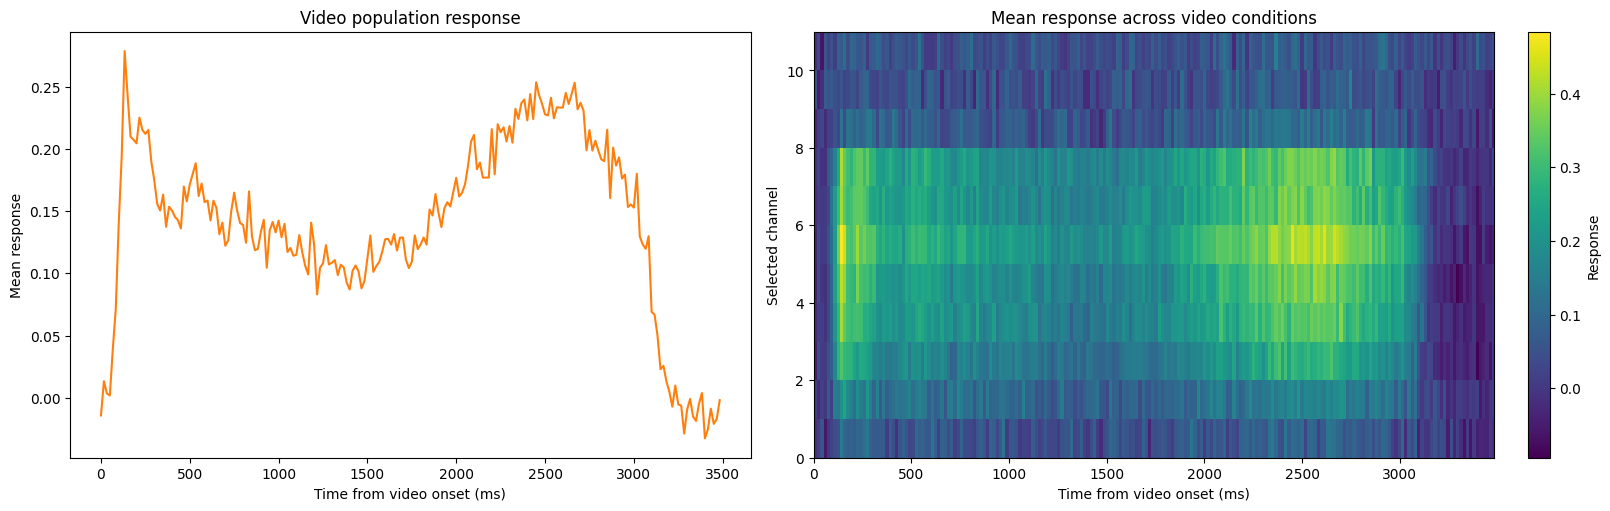

In [115]:
# Show both the population timecourse and the channel-by-time response map.
neural_time_ms = (
    np.arange(video_neural_ts.shape()[1]) * 1000 / video_neural_ts.get_fs()
)
fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
axes[0].plot(
    neural_time_ms,
    video_neural_ts.get_array().mean(axis=(0, 2)),
    color="tab:orange",
)
axes[0].set(
    xlabel="Time from video onset (ms)",
    ylabel="Mean response",
    title="Video population response",
)
response_image = axes[1].imshow(
    video_neural_ts.get_array().mean(axis=2),
    aspect="auto",
    origin="lower",
    extent=[neural_time_ms[0], neural_time_ms[-1], 0, video_neural_ts.shape()[0]],
)
axes[1].set(
    xlabel="Time from video onset (ms)",
    ylabel="Selected channel",
    title="Mean response across video conditions",
)
fig.colorbar(response_image, ax=axes[1], label="Response")


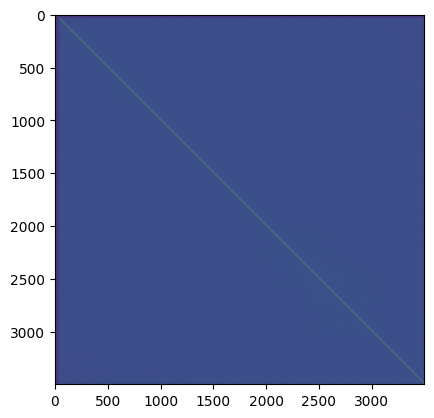

In [123]:
tot_autocorr = None
for i in range(rasters.shape[2]):
    sing_trial = TimeSeries(rasters[:,:,i], fs=cfg.new_fs)
    ac_mat, lp = sing_trial.autocorr()
    if tot_autocorr is None:
        tot_autocorr = ac_mat
    else:
        tot_autocorr += ac_mat

plt.imshow(tot_autocorr/rasters.shape[2])


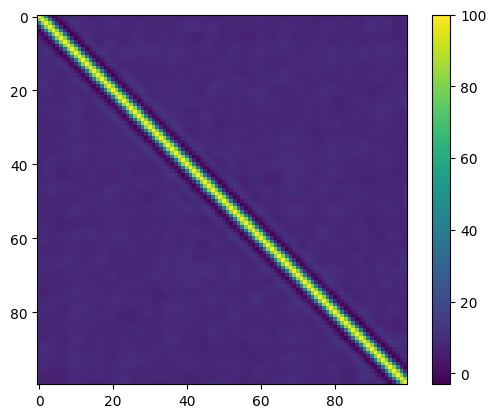

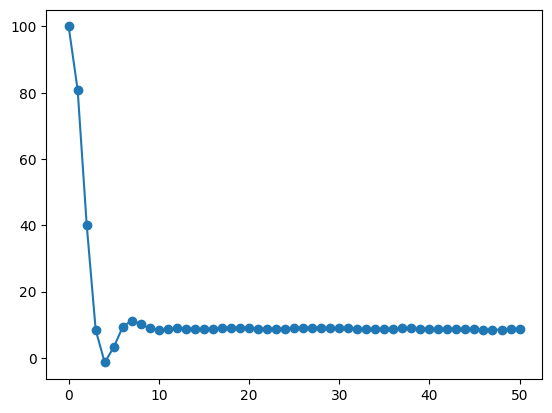

In [140]:
plt.imshow(tot_autocorr[2600:2700, 2600:2700])
plt.colorbar()
plt.figure()
plt.plot(get_lagplot(tot_autocorr[2600:2700, 2600:2700], max_lag=50, symmetric=True), marker="o")

## Align sequential model features

Model HDF5 datasets are reordered to the unchanged neural/MATLAB condition
order before any RDM is computed. Prefix and extension differences do not
affect matching.


In [116]:
model_features_dir = (
    cfg.model_features_dir or Path(paths["data_path"]) / "models"
)
feature_paths = list_video_feature_files(
    model_features_dir,
    cfg.model_name,
    cfg.model_dataset_name,
    cfg.model_pooling,
)
video_feature_names = match_feature_stimulus_names(
    feature_paths[0], video_names,
)

print(f"Model layers: {len(feature_paths)}")
print("First neural-to-model mappings:")
for neural_name, feature_name in zip(video_names[:5], video_feature_names[:5]):
    print(f"  {neural_name} -> {feature_name}")
# end for neural_name, feature_name


Model layers: 24
First neural-to-model mappings:
  vid_0_0_41171.mp4 -> vid_0_0_41171.mp4
  vid_1500_animal_names1.mp4 -> vid_1500_animal_names1.mp4
  vid_4115_11.01.mp4 -> vid_4115_11.01.mp4
  vid_43.81_41411.mp4 -> vid_43.81_41411.mp4
  vid_4_5_41241.mp4 -> vid_4_5_41241.mp4


In [117]:
# Compute the neural RDM once, then replace only the model RDM timecourse.
video_drsa = dRSA(
    signal_RDM_metric=cfg.signal_RDM_metric,
    model_RDM_metric=cfg.model_RDM_metric,
    RSA_metric=cfg.RSA_metric,
)
video_drsa.compute_RDM_timeseries(video_neural_ts, "signal")

video_layer_drsa = {}
layer_names = []
source_model_fs = None
for feature_path in feature_paths:
    model_features, layer_name, layer_model_fs = load_aligned_video_features(
        feature_path, video_feature_names, frame_index=None,
    )

    # Match the model and neural time grids before computing the model RDM timecourse.
    model_ts = TimeSeries(model_features, fs=layer_model_fs)
    model_ts.resample(video_neural_ts.get_fs())
    video_drsa.compute_RDM_timeseries(model_ts, "model")
    video_layer_drsa[layer_name] = video_drsa.compute_dRSA().copy()
    layer_names.append(layer_name)

    if source_model_fs is None:
        source_model_fs = layer_model_fs
    elif source_model_fs != layer_model_fs:
        raise ValueError("Model layers have inconsistent source frame rates.")
    # end if source_model_fs
# end for feature_path

model_fs = video_neural_ts.get_fs()
print(
    f"Video dRSA: {len(video_layer_drsa)} layers; "
    f"model features resampled from {source_model_fs:g} to {model_fs:g} Hz"
)

Video dRSA: 24 layers; model features resampled from 60 to 60 Hz


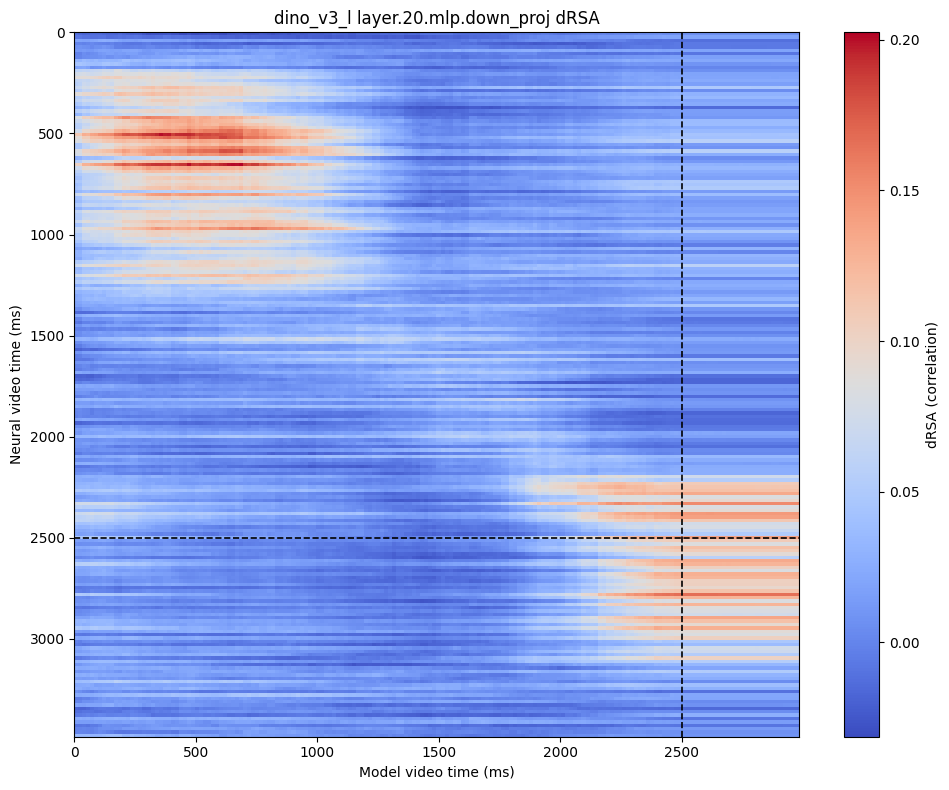

In [119]:
if not 0 <= cfg.example_layer_index < len(layer_names):
    raise IndexError(
        f"example_layer_index must be between 0 and {len(layer_names) - 1}"
    )
# end if example_layer_index

example_layer = layer_names[cfg.example_layer_index]
example_video_drsa = video_layer_drsa[example_layer]
neural_time_ms = (
    np.arange(example_video_drsa.shape[0]) * 1000 / video_neural_ts.get_fs()
)
model_time_ms = np.arange(example_video_drsa.shape[1]) * 1000 / model_fs

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(
    example_video_drsa,
    aspect="auto",
    origin="upper",
    cmap="coolwarm",
    extent=[
        model_time_ms[0], model_time_ms[-1],
        neural_time_ms[-1], neural_time_ms[0],
    ],
)
ax.set(
    xlabel="Model video time (ms)",
    ylabel="Neural video time (ms)",
    title=f"{cfg.model_name} {example_layer} dRSA",
)
ax.axvline(
    cfg.image_onset_ms, color="black", linestyle="--", linewidth=1.2,
)
ax.axhline(
    cfg.image_onset_ms, color="black", linestyle="--", linewidth=1.2,
)
fig.colorbar(image, ax=ax, label=f"dRSA ({cfg.RSA_metric})")
fig.tight_layout()


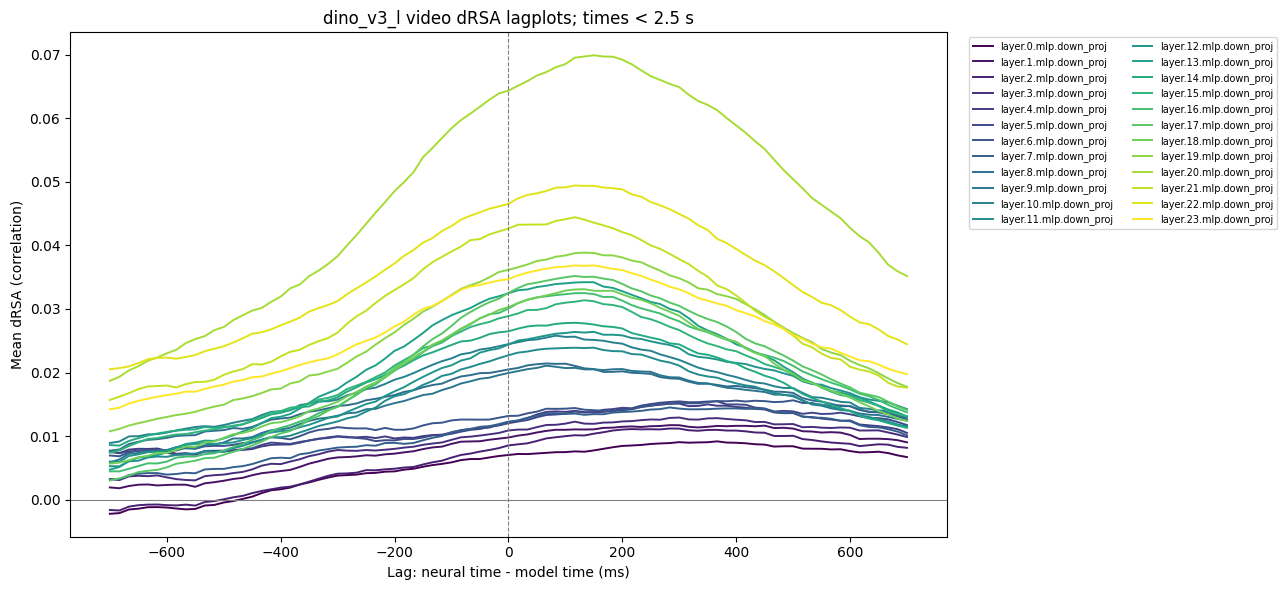

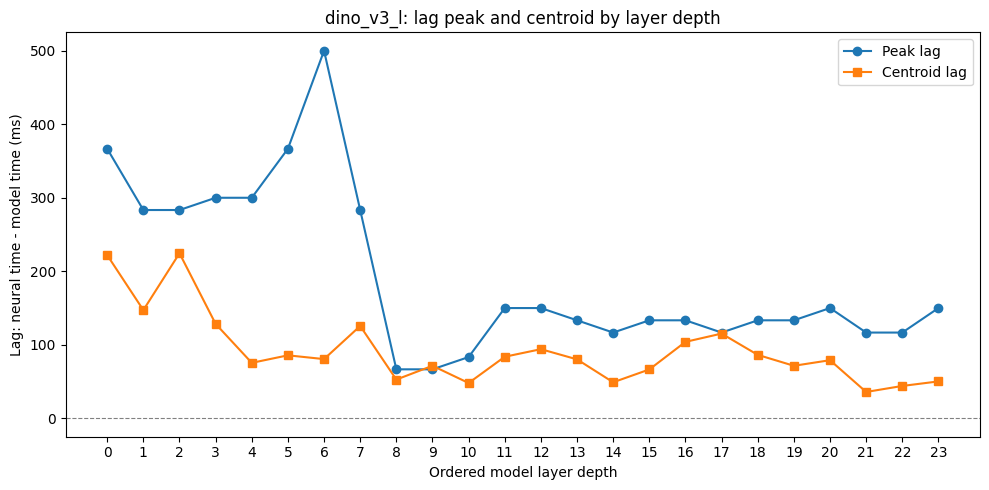

In [110]:
# Both dRSA axes now share one sampling rate, so index diagonals are physical lags.
lag_fs = video_neural_ts.get_fs()
analysis_end_index = int(np.ceil(cfg.lag_analysis_end_ms * lag_fs / 1000))
max_lag_samples = int(round(cfg.max_lag_ms * lag_fs / 1000))
lag_ms = np.arange(-max_lag_samples, max_lag_samples + 1) * 1000 / lag_fs

video_layer_lagplots = []
for layer_name in layer_names:
    layer_drsa = video_layer_drsa[layer_name]
    neural_idx = np.arange(min(analysis_end_index, layer_drsa.shape[0]))
    model_idx = np.arange(min(analysis_end_index, layer_drsa.shape[1]))
    layer_lagplot = get_lagplot_subset(
        layer_drsa,
        neural_idx=neural_idx,
        model_idx=model_idx,
        max_lag=max_lag_samples,
    )
    video_layer_lagplots.append(layer_lagplot)  
# end for layer_name
video_layer_lagplots = np.stack(video_layer_lagplots, axis=0)

layer_colors = plt.cm.viridis(np.linspace(0, 1, len(layer_names)))
fig, ax = plt.subplots(figsize=(13, 6))
for layer_index, (layer_name, layer_lagplot) in enumerate(
    zip(layer_names, video_layer_lagplots)
):
    ax.plot(
        lag_ms,
        layer_lagplot,
        color=layer_colors[layer_index],
        linewidth=1.4,
        label=layer_name,
    )
# end for layer_index
ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set(
    xlabel="Lag: neural time - model time (ms)",
    ylabel=f"Mean dRSA ({cfg.RSA_metric})",
    title=(
        f"{cfg.model_name} video dRSA lagplots; "
        f"times < {cfg.lag_analysis_end_ms / 1000:g} s"
    ),
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, ncol=2)
fig.tight_layout()

# Summarize each layer by the lag of its maximum and its positive-weight centroid.
layer_depth = np.arange(len(layer_names))
video_layer_peak_lag_ms = np.full(len(layer_names), np.nan)
video_layer_peak_values = np.full(len(layer_names), np.nan)
for layer_index, layer_lagplot in enumerate(video_layer_lagplots):
    if np.any(np.isfinite(layer_lagplot)):
        peak_index = np.nanargmax(layer_lagplot)
        video_layer_peak_lag_ms[layer_index] = lag_ms[peak_index]
        video_layer_peak_values[layer_index] = layer_lagplot[peak_index]
    # end if finite layer_lagplot
# end for layer_index

video_layer_centroid_lag_ms = 1000 * get_centroid(
    video_layer_lagplots,
    max_lag=max_lag_samples,
    fs=lag_fs,
    min_peak_percent=cfg.centroid_min_peak_percent,
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    layer_depth,
    video_layer_peak_lag_ms,
    marker="o",
    linewidth=1.5,
    label="Peak lag",
)
ax.plot(
    layer_depth,
    video_layer_centroid_lag_ms,
    marker="s",
    linewidth=1.5,
    label="Centroid lag",
)
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set(
    xlabel="Ordered model layer depth",
    ylabel="Lag: neural time - model time (ms)",
    title=f"{cfg.model_name}: lag peak and centroid by layer depth",
    xticks=layer_depth,
)
ax.legend()
fig.tight_layout()


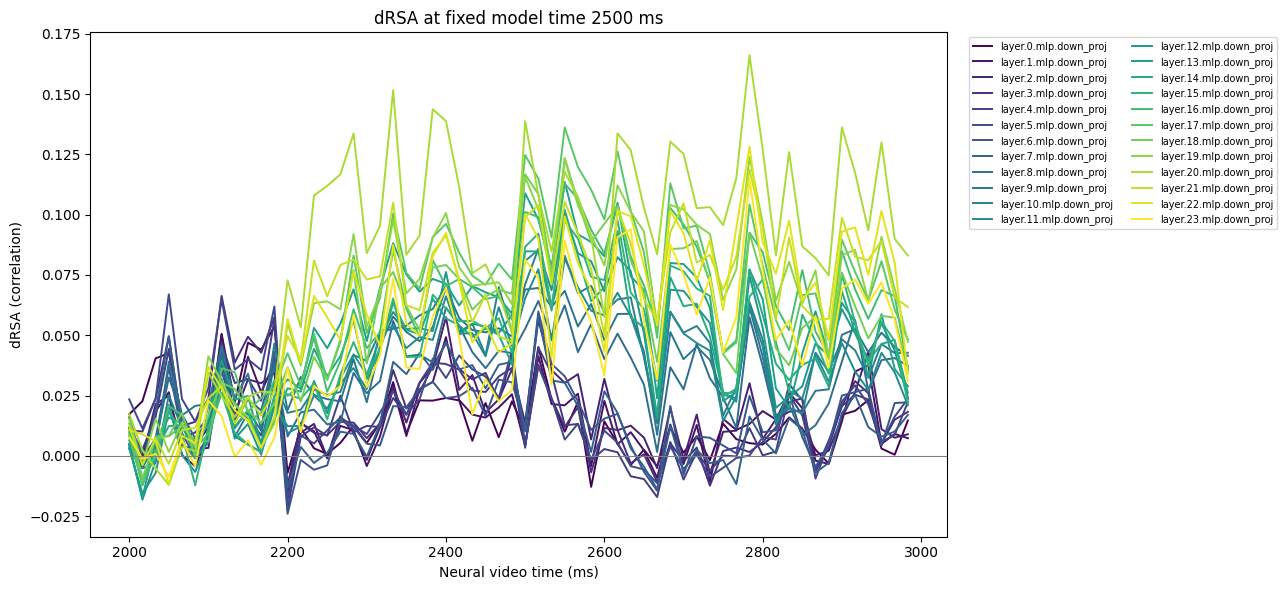

In [111]:
# Plot neural-time dRSA from 2.5 to 3.0 s at a fixed model time of 2.5 s.
model_time_ms = cfg.image_onset_ms
neural_window_ms = np.array([2000, 3000])
analysis_fs = video_neural_ts.get_fs()

model_time_idx = int(round(model_time_ms * analysis_fs / 1000))
neural_start_idx, neural_stop_idx = np.round(
    neural_window_ms * analysis_fs / 1000
).astype(int)
neural_slice_time_ms = (
    np.arange(neural_start_idx, neural_stop_idx) * 1000 / analysis_fs
)

example_shape = next(iter(video_layer_drsa.values())).shape
if not 0 <= model_time_idx < example_shape[1]:
    raise IndexError(
        f"Model time {model_time_ms} ms is outside the dRSA model axis."
    )
# end if model_time_idx
if not 0 <= neural_start_idx < neural_stop_idx <= example_shape[0]:
    raise IndexError(
        f"Neural window {neural_window_ms.tolist()} ms is outside the dRSA neural axis."
    )
# end if neural indices

layer_colors = plt.cm.viridis(np.linspace(0, 1, len(layer_names)))
fig, ax = plt.subplots(figsize=(13, 6))
for layer_index, layer_name in enumerate(layer_names):
    layer_drsa = video_layer_drsa[layer_name]
    slice_drsa = layer_drsa[
        neural_start_idx:neural_stop_idx,
        model_time_idx,
    ]
    ax.plot(
        neural_slice_time_ms,
        slice_drsa,
        color=layer_colors[layer_index],
        linewidth=1.4,
        label=layer_name,
    )
# end for layer_index

ax.axhline(0, color="grey", linewidth=0.8)
ax.set(
    xlabel="Neural video time (ms)",
    ylabel=f"dRSA ({cfg.RSA_metric})",
    title=f"dRSA at fixed model time {model_time_ms} ms",
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, ncol=2)
fig.tight_layout()

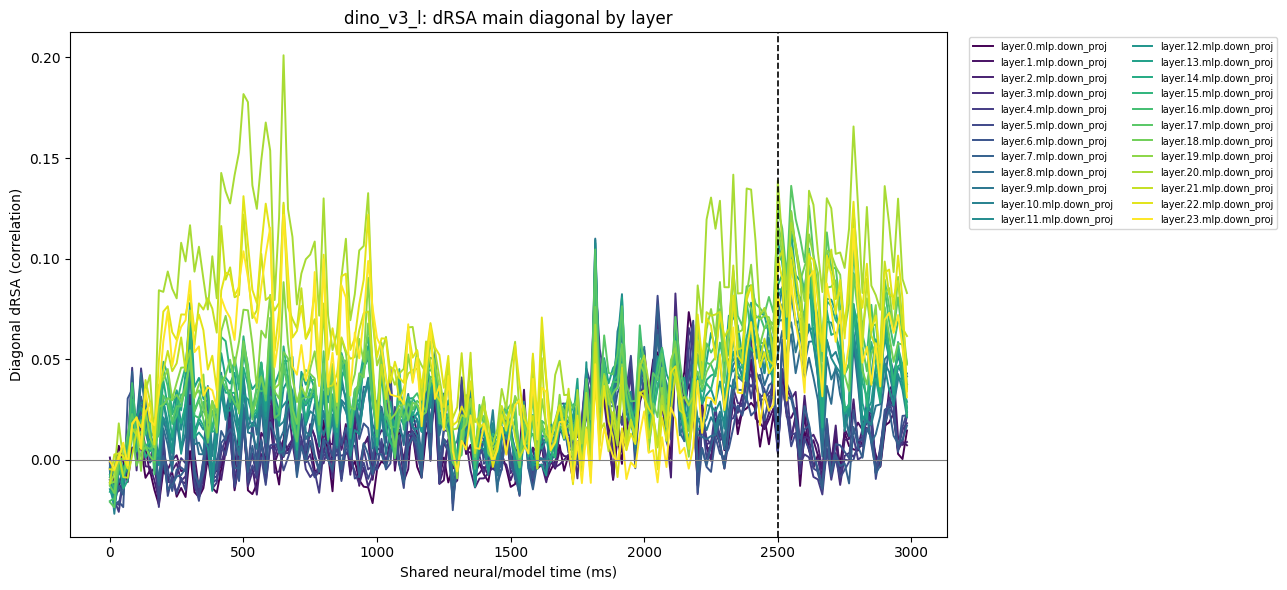

In [112]:
# Extract the main diagonal, where neural time equals model time.
diagonal_fs = video_neural_ts.get_fs()
diagonal_length = min(next(iter(video_layer_drsa.values())).shape)
diagonal_time_ms = np.arange(diagonal_length) * 1000 / diagonal_fs

video_layer_diagonals = []
for layer_name in layer_names:
    layer_diagonal = np.diagonal(video_layer_drsa[layer_name]).copy()
    if layer_diagonal.shape[0] != diagonal_length:
        raise ValueError("dRSA layers have inconsistent diagonal lengths.")
    # end if layer_diagonal.shape[0]
    video_layer_diagonals.append(layer_diagonal)
# end for layer_name
video_layer_diagonals = np.stack(video_layer_diagonals, axis=0)

layer_colors = plt.cm.viridis(np.linspace(0, 1, len(layer_names)))
fig, ax = plt.subplots(figsize=(13, 6))
for layer_index, (layer_name, layer_diagonal) in enumerate(
    zip(layer_names, video_layer_diagonals)
):
    ax.plot(
        diagonal_time_ms,
        layer_diagonal,
        color=layer_colors[layer_index],
        linewidth=1.4,
        label=layer_name,
    )
# end for layer_index

ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(
    cfg.image_onset_ms, color="black", linestyle="--", linewidth=1.2,
)
ax.set(
    xlabel="Shared neural/model time (ms)",
    ylabel=f"Diagonal dRSA ({cfg.RSA_metric})",
    title=f"{cfg.model_name}: dRSA main diagonal by layer",
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, ncol=2)
fig.tight_layout()
